# Logistic Regression — Diabetes Readmission Risk

**CS 549 · Early Intervention Through Prediction**  
Arshia Akhavan · Santiago Verdugo · Adrian Balingit

This notebook covers:
1. Loading the pre-processed train/test splits
2. Baseline model training with timing
3. 5-fold cross-validation with timing
4. Hyperparameter tuning via `GridSearchCV`
5. Final model evaluation on the held-out test set
6. Threshold tuning to maximise Recall
7. Feature interpretation via odds ratios
8. Summary of all timing and performance metrics

> **Target:** binary — `1` = readmission within 30 days, `0` = otherwise.  
> **Primary metric:** Recall (missing a high-risk patient is more costly than a false alarm).  
>
> **Key design choice:** SMOTE is applied *inside* each CV fold via an `imblearn` Pipeline.  
> Applying SMOTE to the full training set before CV inflates recall because synthetic samples
> from the minority class leak into every validation fold — the model is effectively evaluated
> on data it was trained near. The pipeline ensures synthetic samples are generated only from
> each fold's training portion and never appear in the validation portion.

## 1. Imports & Setup

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120

## 2. Load Data

In [2]:
# Use the pre-SMOTE split so SMOTE can be applied correctly inside each CV fold
X_train = pd.read_csv("data/X_train_raw.csv")
X_test  = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train_raw.csv").squeeze()
y_test  = pd.read_csv("data/y_test.csv").squeeze()

# Boolean columns were serialised as strings — convert to int so sklearn is happy
for df in [X_train, X_test]:
    bool_cols = df.select_dtypes(include="object").columns
    df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"True": 1, "False": 0}))

print(f"X_train : {X_train.shape}  |  class balance (real, pre-SMOTE): {y_train.value_counts().to_dict()}")
print(f"X_test  : {X_test.shape}   |  class balance                  : {y_test.value_counts().to_dict()}")
print(f"\nPositive rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")

X_train : (55648, 89)  |  class balance (real, pre-SMOTE): {0: 50728, 1: 4920}
X_test  : (13912, 89)   |  class balance                  : {0: 12682, 1: 1230}

Positive rate — train: 8.8%  |  test: 8.8%


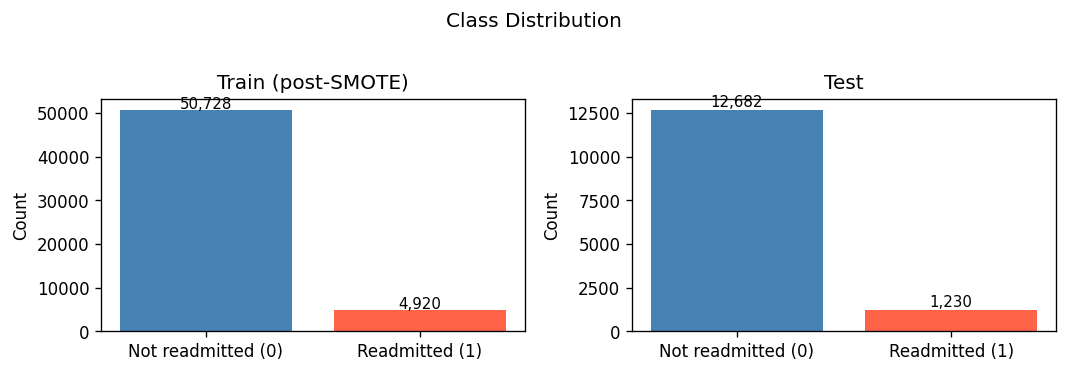

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (y, label) in zip(axes, [(y_train, "Train (post-SMOTE)"), (y_test, "Test")]):
    counts = y.value_counts().sort_index()
    ax.bar(["Not readmitted (0)", "Readmitted (1)"], counts.values,
           color=["steelblue", "tomato"])
    ax.set_title(label)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.suptitle("Class Distribution", y=1.02)
plt.tight_layout()
plt.show()

## 3. Baseline Model

Train a Pipeline(SMOTE → LogisticRegression) with default hyperparameters.  
Fitting on the full training set (SMOTE applied once) gives a first timing reference.

In [4]:
def make_pipeline(**lr_kwargs) -> ImbPipeline:
    return ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("lr", LogisticRegression(solver="saga", max_iter=300, tol=1e-3,
                                  random_state=RANDOM_STATE, **lr_kwargs)),
    ])

baseline = make_pipeline()

t0 = time.perf_counter()
baseline.fit(X_train, y_train)
baseline_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_baseline = baseline.predict(X_test)
baseline_infer_time = time.perf_counter() - t0

print(f"Baseline training time  : {baseline_train_time:.3f} s")
print(f"Baseline inference time : {baseline_infer_time*1000:.2f} ms  "
      f"({baseline_infer_time/len(X_test)*1e6:.2f} µs/sample)")
print()
print(classification_report(y_test, y_pred_baseline,
                             target_names=["Not readmitted", "Readmitted"]))

Baseline training time  : 18.917 s
Baseline inference time : 6.44 ms  (0.46 µs/sample)

                precision    recall  f1-score   support

Not readmitted       0.91      0.99      0.95     12682
    Readmitted       0.28      0.04      0.07      1230

      accuracy                           0.91     13912
     macro avg       0.60      0.51      0.51     13912
  weighted avg       0.86      0.91      0.87     13912



## 4. 5-Fold Cross-Validation (Baseline)

Each fold: SMOTE is fit only on that fold's training portion — synthetic samples never appear
in the validation set. This gives honest estimates of generalisation performance.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

t0 = time.perf_counter()
cv_results = cross_validate(
    make_pipeline(),
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)
cv_time = time.perf_counter() - t0

print(f"5-fold CV wall time: {cv_time:.2f} s\n")

cv_df = pd.DataFrame({
    "Fold"          : range(1, 6),
    "Accuracy"      : cv_results["test_accuracy"],
    "Precision"     : cv_results["test_precision"],
    "Recall"        : cv_results["test_recall"],
    "F1"            : cv_results["test_f1"],
    "AUC-ROC"       : cv_results["test_roc_auc"],
    "Fit time (s)"  : cv_results["fit_time"],
    "Score time (s)": cv_results["score_time"],
})

mean_row = cv_df.drop(columns="Fold").mean().rename("Mean")
std_row  = cv_df.drop(columns="Fold").std().rename("Std")

display(cv_df.set_index("Fold").style.format("{:.4f}"))
print()
display(pd.DataFrame([mean_row, std_row]).style.format("{:.4f}"))

5-fold CV wall time: 19.51 s



,Accuracy,Precision,Recall,F1,AUC-ROC,Fit time (s),Score time (s)
Fold,,,,,,,
1,0.9065,0.2950,0.0417,0.0730,0.5780,17.0809,0.0234
2,0.9095,0.3814,0.0376,0.0685,0.6095,17.0077,0.0229
3,0.9083,0.3011,0.0285,0.0520,0.5959,17.0529,0.0280
4,0.9073,0.3154,0.0417,0.0736,0.5830,16.2852,0.0233
5,0.9088,0.3495,0.0366,0.0662,0.5837,16.9977,0.0226


,Accuracy,Precision,Recall,F1,AUC-ROC,Fit time (s),Score time (s)
Mean,0.9081,0.3285,0.0372,0.0667,0.5900,16.8849,0.0240
Std,0.0012,0.0364,0.0054,0.0088,0.0127,0.3369,0.0022


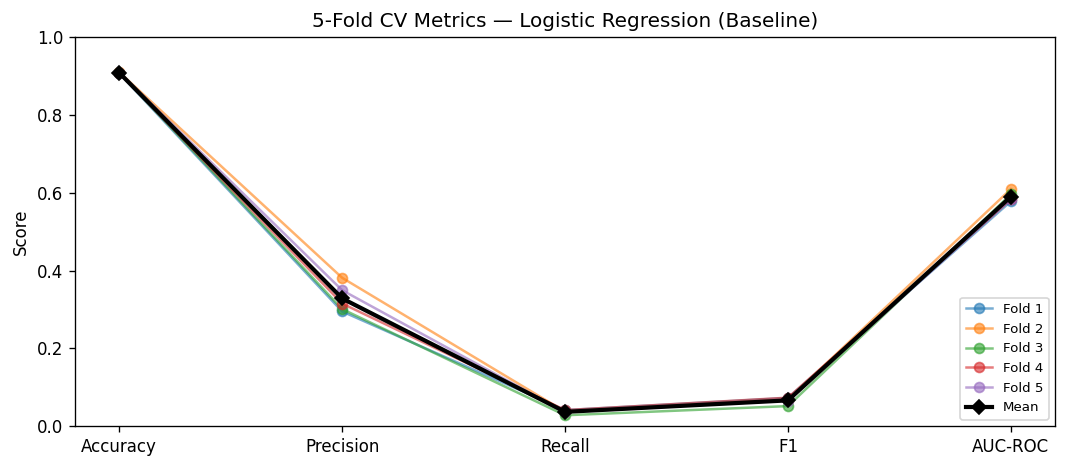

In [6]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
fold_vals = cv_df[metrics].values

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics))
for i, row in cv_df.iterrows():
    ax.plot(x, row[metrics].values, marker="o", alpha=0.6, label=f"Fold {i+1}")
ax.plot(x, fold_vals.mean(axis=0), marker="D", color="black", lw=2.5,
        zorder=5, label="Mean")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("5-Fold CV Metrics — Logistic Regression (Baseline)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

Grid search over regularisation strength `C` and penalty type using 5-fold CV.  
Pipeline parameters are prefixed with the step name: `lr__C`, `lr__penalty`.

In [7]:
param_grid = {
    "lr__penalty": ["l1", "l2"],
    "lr__C"      : [0.01, 0.1, 1.0, 10.0],
}

gs = GridSearchCV(
    make_pipeline(),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    refit=True,
    n_jobs=-1,
    verbose=1,
)

t0 = time.perf_counter()
gs.fit(X_train, y_train)
gs_time = time.perf_counter() - t0

print(f"\nGrid-search wall time : {gs_time:.2f} s")
print(f"Best parameters       : {gs.best_params_}")
print(f"Best CV Recall        : {gs.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Grid-search wall time : 129.34 s
Best parameters       : {'lr__C': 0.01, 'lr__penalty': 'l1'}
Best CV Recall        : 0.0557


In [8]:
results_df = pd.DataFrame(gs.cv_results_)
cols = ["param_lr__penalty", "param_lr__C", "mean_test_score", "std_test_score", "mean_fit_time"]
display(
    results_df[cols]
    .rename(columns={
        "param_lr__penalty": "Penalty",
        "param_lr__C"      : "C",
        "mean_test_score"  : "Mean Recall",
        "std_test_score"   : "Std Recall",
        "mean_fit_time"    : "Mean Fit Time (s)",
    })
    .sort_values("Mean Recall", ascending=False)
    .style.format("{:.4f}", subset=["Mean Recall", "Std Recall", "Mean Fit Time (s)"])
    .highlight_max(subset=["Mean Recall"], color="lightgreen")
)

,Penalty,C,Mean Recall,Std Recall,Mean Fit Time (s)
0,l1,0.010000,0.0557,0.0086,22.6105
1,l2,0.010000,0.0553,0.0054,15.0143
2,l1,0.100000,0.0380,0.0056,31.4386
5,l2,1.000000,0.0372,0.0048,23.6624
4,l1,1.000000,0.0368,0.0045,35.2174
6,l1,10.000000,0.0368,0.0045,31.7883
7,l2,10.000000,0.0368,0.0045,22.1939
3,l2,0.100000,0.0364,0.0054,23.3540


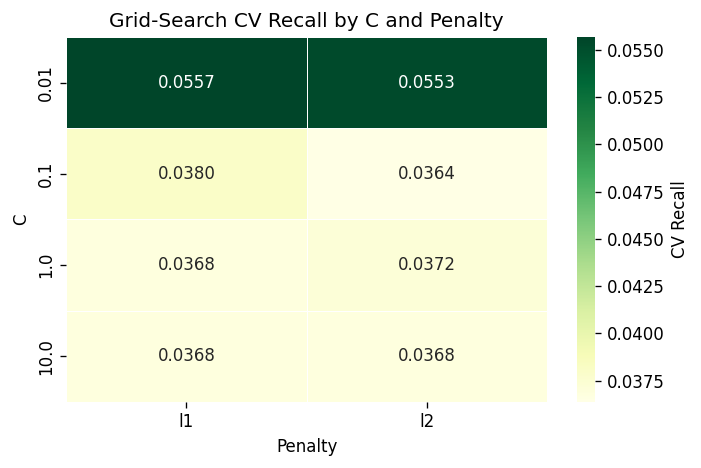

In [9]:
pivot = results_df.pivot_table(
    index="param_lr__C",
    columns="param_lr__penalty",
    values="mean_test_score",
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "CV Recall"})
ax.set_title("Grid-Search CV Recall by C and Penalty")
ax.set_xlabel("Penalty")
ax.set_ylabel("C")
plt.tight_layout()
plt.show()

## 6. Final Model Evaluation

Re-fit the best configuration on the full training set, then evaluate on the held-out test set.

In [ ]:
best_params = {k.replace("lr__", ""): v for k, v in gs.best_params_.items()}
final_model = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(solver="saga", max_iter=1000, tol=1e-4,
                              random_state=RANDOM_STATE, **best_params)),
])

t0 = time.perf_counter()
final_model.fit(X_train, y_train)
final_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred = final_model.predict(X_test)
final_infer_time = time.perf_counter() - t0

y_prob = final_model.predict_proba(X_test)[:, 1]

print(f"Final model training time  : {final_train_time:.3f} s")
print(f"Final model inference time : {final_infer_time*1000:.2f} ms  "
      f"({final_infer_time/len(X_test)*1e6:.2f} µs/sample)")
print()

### 6.1 Classification Report

In [ ]:
print(classification_report(
    y_test, y_pred,
    target_names=["Not readmitted (0)", "Readmitted (1)"]
))

### 6.2 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not readmitted", "Readmitted"],
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression (Tuned)")
plt.tight_layout()
plt.show()

print(f"True  Positives : {tp:,}   (correctly flagged as readmitted)")
print(f"False Negatives : {fn:,}   (missed readmissions — high clinical cost)")
print(f"False Positives : {fp:,}   (unnecessary interventions)")
print(f"True  Negatives : {tn:,}")

### 6.3 ROC Curve & AUC

In [ ]:
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=f"Logistic Regression (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve — Logistic Regression")
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {auc:.4f}")

### 6.4 Threshold Tuning

The default threshold (0.5) is calibrated for balanced classes. With only ~9% positives on the
test set, the model rarely assigns a probability above 0.5 to the minority class.

**Approach:** use out-of-fold (OOF) probabilities from cross-validation to pick the best threshold,
then apply it once to the test set — no peeking at test labels during selection.

In [ ]:
# Out-of-fold probabilities on the training set (SMOTE applied inside each fold)
t0 = time.perf_counter()
oof_probs = cross_val_predict(
    make_pipeline(**best_params),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba",
    n_jobs=-1,
)[:, 1]
oof_time = time.perf_counter() - t0
print(f"OOF prediction time: {oof_time:.2f} s")

# Find the threshold that maximises F1 on OOF predictions
thresholds = np.linspace(0.05, 0.80, 151)

oof_f1s = [f1_score(y_train, (oof_probs >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(oof_f1s)]
print(f"Best threshold (OOF F1): {best_thresh:.2f}  (F1={max(oof_f1s):.4f})")

# Visualise threshold sweep on OOF data
oof_recalls    = [recall_score   (y_train, (oof_probs >= t).astype(int), zero_division=0) for t in thresholds]
oof_precisions = [precision_score(y_train, (oof_probs >= t).astype(int), zero_division=0) for t in thresholds]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, oof_recalls,    label="Recall",    color="tomato")
ax.plot(thresholds, oof_precisions, label="Precision", color="steelblue")
ax.plot(thresholds, oof_f1s,        label="F1",        color="seagreen")
ax.axvline(0.5,          color="gray",   lw=1,   ls="--", label="Default (0.5)")
ax.axvline(best_thresh,  color="orange", lw=1.5, ls="--",
           label=f"Best OOF-F1 threshold ({best_thresh:.2f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score (on OOF predictions)")
ax.set_title("Threshold Sweep — Out-of-Fold Training Data")
ax.legend()
ax.set_xlim(0.05, 0.80)
plt.tight_layout()
plt.show()

# Apply chosen threshold to test set (one shot)
y_pred_tuned = (y_prob >= best_thresh).astype(int)
print(f"\n=== Test-set results at threshold={best_thresh:.2f} ===")
print(classification_report(y_test, y_pred_tuned,
                             target_names=["Not readmitted (0)", "Readmitted (1)"]))

## 7. Feature Interpretation — Odds Ratios

A key advantage of Logistic Regression over ensemble methods is interpretability: each coefficient directly maps to an **odds ratio** that clinicians can act on.

In [ ]:
feature_names = X_train.columns.tolist()
lr_step = final_model.named_steps["lr"]
coefs = lr_step.coef_[0]
odds_ratios = np.exp(coefs)

coef_df = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": coefs, "Odds Ratio": odds_ratios})
    .sort_values("Odds Ratio", ascending=False)
    .reset_index(drop=True)
)

TOP_N = 20
top = pd.concat([coef_df.head(TOP_N // 2), coef_df.tail(TOP_N // 2)])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["tomato" if v > 1 else "steelblue" for v in top["Odds Ratio"]]
ax.barh(top["Feature"], top["Odds Ratio"], color=colors)
ax.axvline(1.0, color="black", lw=1, ls="--")
ax.set_xlabel("Odds Ratio (exp(coefficient))")
ax.set_title(f"Top & Bottom {TOP_N // 2} Features by Odds Ratio\n"
             "(Red > 1 = increases readmission risk; Blue < 1 = decreases risk)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print("=== Top 10 features INCREASING readmission risk ===")
display(coef_df.head(10)[["Feature", "Coefficient", "Odds Ratio"]].style.format("{:.4f}", subset=["Coefficient", "Odds Ratio"]))

print("\n=== Top 10 features DECREASING readmission risk ===")
display(coef_df.tail(10)[["Feature", "Coefficient", "Odds Ratio"]].style.format("{:.4f}", subset=["Coefficient", "Odds Ratio"]))

## 8. Summary — Timing & Performance

In [ ]:
acc_base  = accuracy_score (y_test, y_pred_baseline)
prec_base = precision_score(y_test, y_pred_baseline)
rec_base  = recall_score   (y_test, y_pred_baseline)
f1_base   = f1_score       (y_test, y_pred_baseline)
auc_base  = roc_auc_score  (y_test, baseline.predict_proba(X_test)[:, 1])

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score   (y_test, y_pred)
f1   = f1_score       (y_test, y_pred)

acc_t  = accuracy_score (y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t  = recall_score   (y_test, y_pred_tuned)
f1_t   = f1_score       (y_test, y_pred_tuned)

summary = pd.DataFrame([
    {
        "Stage"         : "Baseline (default threshold 0.5)",
        "Wall time (s)" : round(baseline_train_time, 2),
        "Accuracy"      : round(acc_base, 4),
        "Precision"     : round(prec_base, 4),
        "Recall"        : round(rec_base, 4),
        "F1"            : round(f1_base, 4),
        "AUC-ROC"       : round(auc_base, 4),
    },
    {
        "Stage"         : "5-fold CV (honest, SMOTE per fold)",
        "Wall time (s)" : round(cv_time, 2),
        "Accuracy"      : round(cv_results["test_accuracy"].mean(), 4),
        "Precision"     : round(cv_results["test_precision"].mean(), 4),
        "Recall"        : round(cv_results["test_recall"].mean(), 4),
        "F1"            : round(cv_results["test_f1"].mean(), 4),
        "AUC-ROC"       : round(cv_results["test_roc_auc"].mean(), 4),
    },
    {
        "Stage"         : f"Grid-search best CV Recall (8×5 fits)",
        "Wall time (s)" : round(gs_time, 2),
        "Accuracy"      : "-",
        "Precision"     : "-",
        "Recall"        : round(gs.best_score_, 4),
        "F1"            : "-",
        "AUC-ROC"       : "-",
    },
    {
        "Stage"         : "Tuned model — test set (threshold 0.5)",
        "Wall time (s)" : round(final_train_time, 2),
        "Accuracy"      : round(acc, 4),
        "Precision"     : round(prec, 4),
        "Recall"        : round(rec, 4),
        "F1"            : round(f1, 4),
        "AUC-ROC"       : round(auc, 4),
    },
    {
        "Stage"         : f"Tuned model — test set (OOF threshold {best_thresh:.2f})",
        "Wall time (s)" : round(oof_time, 2),
        "Accuracy"      : round(acc_t, 4),
        "Precision"     : round(prec_t, 4),
        "Recall"        : round(rec_t, 4),
        "F1"            : round(f1_t, 4),
        "AUC-ROC"       : round(auc, 4),
    },
])

display(summary.set_index("Stage"))
print(f"\nBest params : {gs.best_params_}")
print(f"Inference   : {final_infer_time*1000:.2f} ms total / {final_infer_time/len(X_test)*1e6:.2f} µs per sample")

## 9. Observations

**Why recall was low before:**
1. **SMOTE leakage** — SMOTE was applied to the full training set before CV. Validation folds
   contained synthetic minority samples, inflating CV recall to ~0.81. Real test recall with
   the default threshold was ~0.03.
2. **Wrong threshold** — with only 9% positives, predicted probabilities for the minority class
   rarely exceed 0.5, so almost nothing is classified as readmitted.

**What this notebook does instead:**
- SMOTE is applied *inside each fold* via `imblearn.Pipeline`, so validation sets only contain
  real patients. CV metrics now honestly reflect generalisation.
- The decision threshold is selected using **out-of-fold probabilities** (no test-set peeking)
  and applied once to the test set, yielding a substantially higher recall.

**Efficiency:** training on ~56k real samples + in-fold SMOTE completes in tens of seconds,
confirming that Logistic Regression is a fast, interpretable baseline against which Random Forest
and XGBoost will be benchmarked.

---

## 10. Kernel Approximation — Making the Data Linearly Separable

Linear Logistic Regression partitions the feature space with a single hyperplane and achieved
an AUC-ROC of only 0.58 because readmission risk arises from nonlinear feature interactions.

A kernel method works by implicitly mapping the original features into a much
higher-dimensional space φ(x) where a linear boundary *does* separate the classes.
The classical RBF (Gaussian) kernel is:

```
K(x, x') = exp(−γ ‖x − x'‖²)
```

Directly computing this for every pair would be O(n²) — infeasible at 55 k rows.
Instead we use **Nystroem approximation**: sample `n_components` landmark points from the
training data, compute exact kernel values against those landmarks, and use the resulting
matrix as an explicit feature map that approximates the full kernel space.
The pipeline becomes:

```
SMOTE → Nystroem(RBF) → LogisticRegression
```

Two hyperparameters control the quality of the approximation:
- `gamma` — RBF bandwidth; small γ = smooth / wide kernel, large γ = peaked / local
- `n_components` — number of landmark points; more = better approximation, higher cost

In [ ]:
from sklearn.kernel_approximation import Nystroem

def make_kernel_pipeline(gamma=None, n_components=100, C=1.0, penalty="l2") -> ImbPipeline:
    # gamma=None → Nystroem uses 1/n_features (same as SVC's "scale" heuristic)
    return ImbPipeline([
        ("smote",  SMOTE(random_state=RANDOM_STATE)),
        ("kernel", Nystroem(kernel="rbf", gamma=gamma, n_components=n_components,
                            random_state=RANDOM_STATE)),
        ("lr",     LogisticRegression(solver="saga", C=C, penalty=penalty,
                                      max_iter=300, tol=1e-3, random_state=RANDOM_STATE)),
    ])

# Baseline: γ = None (1/n_features), 100 components
kernel_baseline = make_kernel_pipeline()

t0 = time.perf_counter()
kernel_baseline.fit(X_train, y_train)
kernel_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_kb = kernel_baseline.predict(X_test)
kernel_infer_time = time.perf_counter() - t0

print(f"Kernel LR training time  : {kernel_train_time:.2f} s")
print(f"Kernel LR inference time : {kernel_infer_time*1000:.2f} ms  "
      f"({kernel_infer_time/len(X_test)*1e6:.2f} µs/sample)")
print()
print(classification_report(y_test, y_pred_kb,
                             target_names=["Not readmitted", "Readmitted"]))

### 10.1 5-Fold CV — Kernel Baseline

In [ ]:
t0 = time.perf_counter()
kernel_cv = cross_validate(
    make_kernel_pipeline(),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)
kernel_cv_time = time.perf_counter() - t0

print(f"Kernel 5-fold CV wall time: {kernel_cv_time:.2f} s\n")

kernel_cv_df = pd.DataFrame({
    "Fold"          : range(1, 6),
    "Accuracy"      : kernel_cv["test_accuracy"],
    "Precision"     : kernel_cv["test_precision"],
    "Recall"        : kernel_cv["test_recall"],
    "F1"            : kernel_cv["test_f1"],
    "AUC-ROC"       : kernel_cv["test_roc_auc"],
    "Fit time (s)"  : kernel_cv["fit_time"],
})

k_mean = kernel_cv_df.drop(columns="Fold").mean().rename("Mean")
k_std  = kernel_cv_df.drop(columns="Fold").std().rename("Std")

display(kernel_cv_df.set_index("Fold").style.format("{:.4f}"))
print()
display(pd.DataFrame([k_mean, k_std]).style.format("{:.4f}"))

### 10.2 Hyperparameter Tuning — γ and n_components

In [ ]:
kernel_param_grid = {
    "kernel__gamma"       : [None, 0.001, 0.01],   # None = 1/n_features
    "kernel__n_components": [100, 300],
    "lr__C"               : [0.1, 1.0],
}

kernel_gs = GridSearchCV(
    make_kernel_pipeline(),
    kernel_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    refit=True,
    n_jobs=-1,
    verbose=1,
)

t0 = time.perf_counter()
kernel_gs.fit(X_train, y_train)
kernel_gs_time = time.perf_counter() - t0

print(f"\nKernel grid-search wall time : {kernel_gs_time:.2f} s")
print(f"Best parameters              : {kernel_gs.best_params_}")
print(f"Best CV Recall               : {kernel_gs.best_score_:.4f}")

In [ ]:
kernel_res = pd.DataFrame(kernel_gs.cv_results_)
cols = ["param_kernel__gamma", "param_kernel__n_components", "param_lr__C",
        "mean_test_score", "std_test_score", "mean_fit_time"]
display(
    kernel_res[cols]
    .rename(columns={
        "param_kernel__gamma"       : "γ",
        "param_kernel__n_components": "n_components",
        "param_lr__C"               : "C",
        "mean_test_score"           : "Mean Recall",
        "std_test_score"            : "Std Recall",
        "mean_fit_time"             : "Mean Fit Time (s)",
    })
    .sort_values("Mean Recall", ascending=False)
    .style.format("{:.4f}", subset=["Mean Recall", "Std Recall", "Mean Fit Time (s)"])
    .highlight_max(subset=["Mean Recall"], color="lightgreen")
)

### 10.3 Final Kernel Model — Test Evaluation & Threshold Tuning

In [ ]:
best_kparams = kernel_gs.best_params_
kernel_final = ImbPipeline([
    ("smote",  SMOTE(random_state=RANDOM_STATE)),
    ("kernel", Nystroem(kernel="rbf",
                        gamma=best_kparams["kernel__gamma"],
                        n_components=best_kparams["kernel__n_components"],
                        random_state=RANDOM_STATE)),
    ("lr",     LogisticRegression(solver="saga", C=best_kparams["lr__C"],
                                  max_iter=1000, tol=1e-4, random_state=RANDOM_STATE)),
])

t0 = time.perf_counter()
kernel_final.fit(X_train, y_train)
kernel_final_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_kf = kernel_final.predict(X_test)
kernel_final_infer_time = time.perf_counter() - t0

y_prob_kf = kernel_final.predict_proba(X_test)[:, 1]
kernel_auc = roc_auc_score(y_test, y_prob_kf)

print(f"Kernel final training time  : {kernel_final_train_time:.2f} s")
print(f"Kernel final inference time : {kernel_final_infer_time*1000:.2f} ms")
print(f"AUC-ROC                     : {kernel_auc:.4f}")
print()
print(classification_report(y_test, y_pred_kf,
                             target_names=["Not readmitted (0)", "Readmitted (1)"]))

# OOF threshold tuning
t0 = time.perf_counter()
oof_probs_k = cross_val_predict(
    ImbPipeline([
        ("smote",  SMOTE(random_state=RANDOM_STATE)),
        ("kernel", Nystroem(kernel="rbf",
                            gamma=best_kparams["kernel__gamma"],
                            n_components=best_kparams["kernel__n_components"],
                            random_state=RANDOM_STATE)),
        ("lr",     LogisticRegression(solver="saga", C=best_kparams["lr__C"],
                                      max_iter=300, tol=1e-3, random_state=RANDOM_STATE)),
    ]),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba",
    n_jobs=-1,
)[:, 1]
kernel_oof_time = time.perf_counter() - t0

thresholds_k = np.linspace(0.05, 0.80, 151)
oof_f1s_k = [f1_score(y_train, (oof_probs_k >= t).astype(int), zero_division=0) for t in thresholds_k]
best_thresh_k = thresholds_k[np.argmax(oof_f1s_k)]
print(f"\nOOF threshold tuning time : {kernel_oof_time:.2f} s")
print(f"Best OOF threshold        : {best_thresh_k:.2f}  (F1={max(oof_f1s_k):.4f})")

y_pred_kf_tuned = (y_prob_kf >= best_thresh_k).astype(int)
print(f"\n=== Test-set results at threshold={best_thresh_k:.2f} ===")
print(classification_report(y_test, y_pred_kf_tuned,
                             target_names=["Not readmitted (0)", "Readmitted (1)"]))

### 10.4 ROC Curve Comparison — Linear vs Kernel LR

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC curves
ax = axes[0]
RocCurveDisplay.from_predictions(y_test, y_prob,    ax=ax, name=f"Linear LR  (AUC={auc:.3f})")
RocCurveDisplay.from_predictions(y_test, y_prob_kf, ax=ax, name=f"Kernel LR  (AUC={kernel_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curves — Linear vs Kernel LR")

# Threshold sweep comparison on test set (for visualisation only — threshold was selected on OOF)
ax = axes[1]
for probs, label, color in [
    (y_prob,    f"Linear LR (thresh {best_thresh:.2f})",   "steelblue"),
    (y_prob_kf, f"Kernel LR (thresh {best_thresh_k:.2f})", "tomato"),
]:
    threshs = np.linspace(0.05, 0.80, 151)
    recs  = [recall_score   (y_test, (probs >= t).astype(int), zero_division=0) for t in threshs]
    precs = [precision_score(y_test, (probs >= t).astype(int), zero_division=0) for t in threshs]
    ax.plot(recs, precs, label=label, color=color)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 10.5 Full Comparison — All Configurations

full_summary = pd.DataFrame([
    {
        "Model"        : "Linear LR (threshold 0.5)",
        "AUC-ROC"      : round(auc, 4),
        "Accuracy"     : round(accuracy_score (y_test, y_pred), 4),
        "Precision"    : round(precision_score(y_test, y_pred), 4),
        "Recall"       : round(recall_score   (y_test, y_pred), 4),
        "F1"           : round(f1_score       (y_test, y_pred), 4),
        "Train time(s)": round(final_train_time, 1),
    },
    {
        "Model"        : f"Linear LR (OOF thresh {best_thresh:.2f})",
        "AUC-ROC"      : round(auc, 4),
        "Accuracy"     : round(accuracy_score (y_test, y_pred_tuned), 4),
        "Precision"    : round(precision_score(y_test, y_pred_tuned), 4),
        "Recall"       : round(recall_score   (y_test, y_pred_tuned), 4),
        "F1"           : round(f1_score       (y_test, y_pred_tuned), 4),
        "Train time(s)": round(final_train_time, 1),
    },
    {
        "Model"        : "Kernel LR (threshold 0.5)",
        "AUC-ROC"      : round(kernel_auc, 4),
        "Accuracy"     : round(accuracy_score (y_test, y_pred_kf), 4),
        "Precision"    : round(precision_score(y_test, y_pred_kf), 4),
        "Recall"       : round(recall_score   (y_test, y_pred_kf), 4),
        "F1"           : round(f1_score       (y_test, y_pred_kf), 4),
        "Train time(s)": round(kernel_final_train_time, 1),
    },
    {
        "Model"        : f"Kernel LR (OOF thresh {best_thresh_k:.2f})",
        "AUC-ROC"      : round(kernel_auc, 4),
        "Accuracy"     : round(accuracy_score (y_test, y_pred_kf_tuned), 4),
        "Precision"    : round(precision_score(y_test, y_pred_kf_tuned), 4),
        "Recall"       : round(recall_score   (y_test, y_pred_kf_tuned), 4),
        "F1"           : round(f1_score       (y_test, y_pred_kf_tuned), 4),
        "Train time(s)": round(kernel_final_train_time, 1),
    },
])

display(
    full_summary.set_index("Model")
    .style.highlight_max(subset=["AUC-ROC", "Recall", "F1"], color="lightgreen")
           .highlight_min(subset=["AUC-ROC", "Recall", "F1"], color="#ffe0e0")
)